In [ ]:
import warnings
warnings.filterwarnings("ignore", message="A module that was compiled using NumPy 1.x")

# pyTelops + LDAQ: Synchronized Multi-Sensor Acquisition

**The Telops camera as a peer of NI DAQmx, FLIR, and Basler: one Python API, one synchronized acquisition.**

This notebook shows pyTelops integrated into [LDAQ](https://github.com/ladisk/LDAQ), the Ladisk research group's open-source data acquisition framework. LDAQ already supports National Instruments DAQmx, Digilent, FLIR cameras, Basler cameras, Arduino/ESP serial, and DEWESoft. Adding pyTelops as a Python-native, SDK-free thermal source is straight forward:

> **Customers can run a Telops camera alongside their NI accelerometers, force sensors, and strain gauges in one synchronized Python pipeline**

## 1. Imports

`LDAQ.telops.TelopsCamera` is a built-in submodule of LDAQ (mirrors `LDAQ.flir`, `LDAQ.basler`, `LDAQ.national_instruments`).

In [24]:
import numpy as np
import matplotlib.pyplot as plt

import LDAQ;

## 2. Source 1: Telops thermal camera

One line of code creates the source. The plugin owns the camera lifecycle (connect → configure → start acquisition → stop → disconnect); LDAQ Core sees it as a regular `BaseAcquisition`.

In [25]:
telops_source = LDAQ.telops.TelopsCamera(
    acquisition_name="thermal",
    sample_rate=5.0,            # Hz, conservative for clean live preview
    integration_time=50.0,       # microseconds
    calibration_mode="RT",       # radiometric temperature (Celsius)
    packet_delay=2000,           # ~16us between packets, spreads per-frame burst
                                 # so Qt hiccups can't overflow the UDP queue
)

## 3. Source 2: NI DAQmx accelerometer

This cell wires in a real National Instruments accelerometer via LDAQ's built-in `NIAcquisition` source. Two ways to configure it:

- **Task from NI-MAX** (default below): reference an acquisition task you already set up in NI Measurement & Automation Explorer. Just pass its name as a string.
- **Programmatic NITask** (alternative, commented out below): create the task in Python via `LDAQ.national_instruments.NITask`, add channels with sensitivity and units, skip NI-MAX entirely.

Both approaches produce a source that plugs into `LDAQ.Core` the same way as the Telops camera

In [26]:
NI_TASK_NAME = "AccelerationTask"

accel_source = LDAQ.national_instruments.NIAcquisition(
    task_name=NI_TASK_NAME,
    acquisition_name="accel",
)

## 4. Build the LDAQ Core with a live-preview GUI

This is where LDAQ earns its keep. We build a `LDAQ.Visualization` object, attach it to the `Core`, and run. LDAQ opens a Qt window with:

- **Live line plot** of the NI accelerometer channels, updating at the configured refresh rate (100 ms by default)
- **Live thermal image** of the Telops camera frames, inferno colormap
- **`Start Measurement` button**, the record button, click it when you're ready to capture a synchronized run
- **`Stop` / `Close` / `Freeze` / `Full Screen` / `Toggle Legends` buttons**, standard live-view controls

The whole thing is **three method calls**: `add_lines`, `add_image`, `Core(..., visualization=vis)`. No Qt code, no event loop setup, no custom widgets. The same pattern works for any combination of acquisition sources: NI + Telops here, but could be FLIR + Basler + Digilent + Dewesoft in the same window.

In [27]:
# --- 1) Build the live-preview GUI -------------------------------
vis = LDAQ.Visualization(refresh_rate=100)

# Live line plot, acceleration only (channel 1)
# AccelerationTask channels: [voltage=0, acceleration=1, force=2]
vis.add_lines(position=(0, 0), source="accel", channels=[1])
vis.config_subplot((0, 0),
                    title="NI acceleration",
                    t_span=2.0)

# Live thermal image, Telops camera video channel
vis.add_image(source="thermal", channel="thermal_field",
              colormap="CET-L17")

# --- 2) Build the Core with the visualization attached -----------
core = LDAQ.Core(
    acquisitions=[telops_source, accel_source],
    visualization=vis,
)

# --- 3) Run ------------------------------------------------------
core.run(
    measurement_duration=5.0,
    autoclose=True,
    autostart=False,
)

closing app
closing app


## 5. Extract the measurement

`get_measurement_dict()` returns one dict per acquisition source containing time, data, channel names, and (for video sources) frame stacks.

In [28]:
meas = core.get_measurement_dict()

# NI: pull only the acceleration channel (index 1)
acc_meas     = meas["accel"]
t_acc        = acc_meas["time"]
acceleration = acc_meas["data"][:, 1]

# Thermal video, one (n_frames, H, W) array per video channel
tel = meas["thermal"]
t_tel  = tel["time"]
frames = tel["video"][0]

print(f"Acceleration:   {acceleration.shape[0]} samples over {t_acc[-1]:.2f} s")
print(f"                ({acceleration.shape[0]/t_acc[-1]:.0f} Hz effective)")
print(f"Thermal frames: {frames.shape[0]} over {t_tel[-1]:.2f} s")
print(f"                ({frames.shape[0]/t_tel[-1]:.0f} fps effective)")
print(f"Frame shape:    {frames.shape[1:]} (H, W)")

Acceleration:   128000 samples over 5.00 s
                (25600 Hz effective)
Thermal frames: 25 over 4.80 s
                (5 fps effective)
Frame shape:    (256, 320) (H, W)


## 6. Plot the synchronized timeline

Both sources share **one common time axis**. The accelerometer waveform and the camera's mean temperature trace are plotted together.

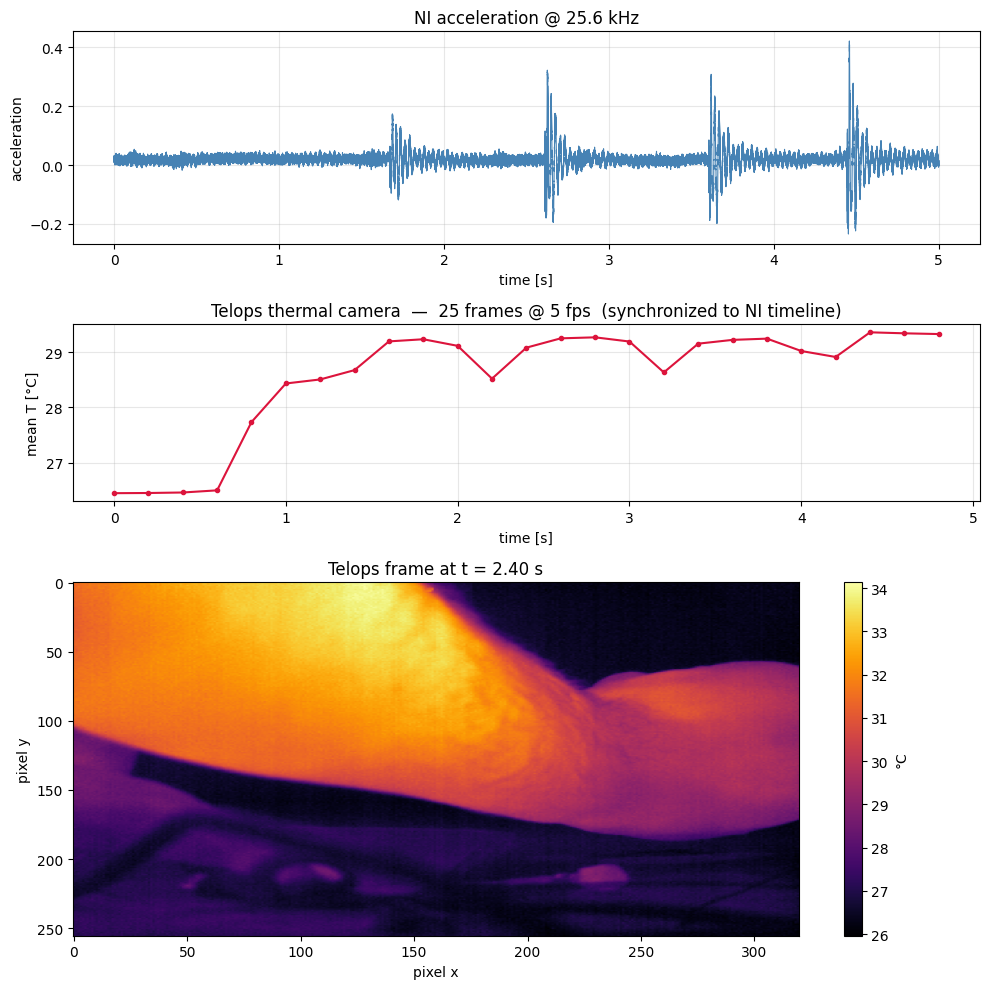

In [29]:
mean_temps = frames.mean(axis=(1, 2))

fig, axes = plt.subplots(3, 1, figsize=(10, 10),
                          gridspec_kw={"height_ratios": [1.2, 1, 2]})

# Acceleration (the structural response signal from the NI task)
axes[0].plot(t_acc, acceleration, lw=0.8, color="steelblue")
axes[0].set_xlabel("time [s]")
axes[0].set_ylabel("acceleration")
axes[0].set_title("NI acceleration @ 25.6 kHz")
axes[0].grid(alpha=0.3)

# Thermal mean temperature over the same time window
axes[1].plot(t_tel, mean_temps, lw=1.5, color="crimson", marker="o", ms=3)
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("mean T [°C]")
axes[1].set_title(
    f"Telops thermal camera: {len(t_tel)} frames "
    f"@ {len(t_tel)/t_tel[-1]:.0f} fps  (synchronized to NI timeline)"
)
axes[1].grid(alpha=0.3)

# Sample thermal frame from the middle of the recording
mid_idx = len(t_tel) // 2
im = axes[2].imshow(frames[mid_idx], cmap="inferno", aspect="auto")
axes[2].set_title(f"Telops frame at t = {t_tel[mid_idx]:.2f} s")
axes[2].set_xlabel("pixel x")
axes[2].set_ylabel("pixel y")
plt.colorbar(im, ax=axes[2], label="°C")

plt.tight_layout()
plt.show()

In [ ]:
cam.disconnect()
print(f"State: {cam.state}")

NameError: name 'cam' is not defined

: 

---

## Conclusion

- **Two acquisition sources, one Python API.** TelopsCamera and NI/simulated accelerometer were defined the same way, passed into the same `Core`, and executed in one call.
- **No vendor SDK.** No eBUS, no NI MAX configuration, no PySpin or pypylon. Pure Python + numpy.
- **Synchronized timestamps.** Both sources share a common time axis managed by LDAQ Core. Events can be cross-correlated.
- **Same code runs on real hardware.** Swap `LDAQ.simulator.SimulatedAcquisition` for `LDAQ.national_instruments.NIAcquisition`. Nothing else changes.
- **Same code runs with FLIR or Basler cameras** in place of Telops. The `BaseAcquisition` contract is camera-agnostic.

**This is what "standalone lightweight framework" looks like in practice:** a `pip install`, a few lines of Python, and you have a multi-modal test rig that would otherwise require coordinating multiple commercial GUIs and SDKs.